In [55]:
import numpy as np
import matplotlib.pyplot as plt
import random
import scipy.io

# Parameters
dx = 0.01  # Spatial step
dt = 0.005  # Time step
Nx = int(2/dx)
Nt = int(1/dt)
x = np.linspace(-1, 1, Nx)
t = np.linspace(0, 1, Nt)

diff_coeff = 0.0001
num_samples = 10000  # Number of different initial conditions

# Initial condition
def initial_condition(x):
    return (
        random.uniform(0, 1) * x**2 * np.cos(np.pi * x) +
        random.uniform(0, 1) * x**4 * np.cos(2 * np.pi * x) +
        random.uniform(0, 1) * x**2 * np.sin(np.pi * x) +
        random.uniform(0, 1) * x**4 * np.sin(2 * np.pi * x) 
        + random.uniform(0, 1) * x**6 * np.sin(3 * np.pi * x) +
        random.uniform(0, 1) * x**6 * np.cos(3 * np.pi * x)
    )

# Define the function f(u) = 5u^3 - 5u
def nonlinearity(u):
    return 5 * u**3 - 5 * u

# Storage arrays
s_train = np.zeros((num_samples, Nx, 1))
u_train = np.zeros((num_samples, Nx, Nt))

# Generate dataset
for sample in range(num_samples):
    u = np.zeros((Nt, Nx))
    u[0, :] = initial_condition(x)
    s_train[sample, :, 0] = u[0, :]
    
    # Time stepping loop using explicit Euler
    for n in range(0, Nt - 1):
        u_n = u[n, :]
        u_next = np.copy(u_n)
        
        # Compute spatial second derivative using central difference
        u_xx = np.zeros(Nx)
        u_xx[1:-1] = (u_n[:-2] - 2 * u_n[1:-1] + u_n[2:]) / dx**2
        
        # Update using explicit Euler method
        u_next[1:-1] = u_n[1:-1] + dt * (diff_coeff * u_xx[1:-1] - nonlinearity(u_n[1:-1]))
        
        # Apply periodic boundary conditions
        u_next[0] = u_next[-2]  # u(t, -1) = u(t, 1)
        u_next[-1] = u_next[1]
        
        # Derivative periodic boundary condition
        u_next[0] = u_next[-2]  # u_x(t, -1) = u_x(t, 1)
        u_next[-1] = u_next[1]
        
        u[n + 1, :] = u_next
    
    u_train[sample, :, :] = u.T  # Store solution field

# Save data as .npz
np.savez('Allen_Cahn_6_terms_more_resolution.npz', s_train=s_train, u_train=u_train)

# Save data as .mat
scipy.io.savemat('Allen_Cahn_6_terms_more_resolution.mat', {'s_train': s_train, 'u_train': u_train})


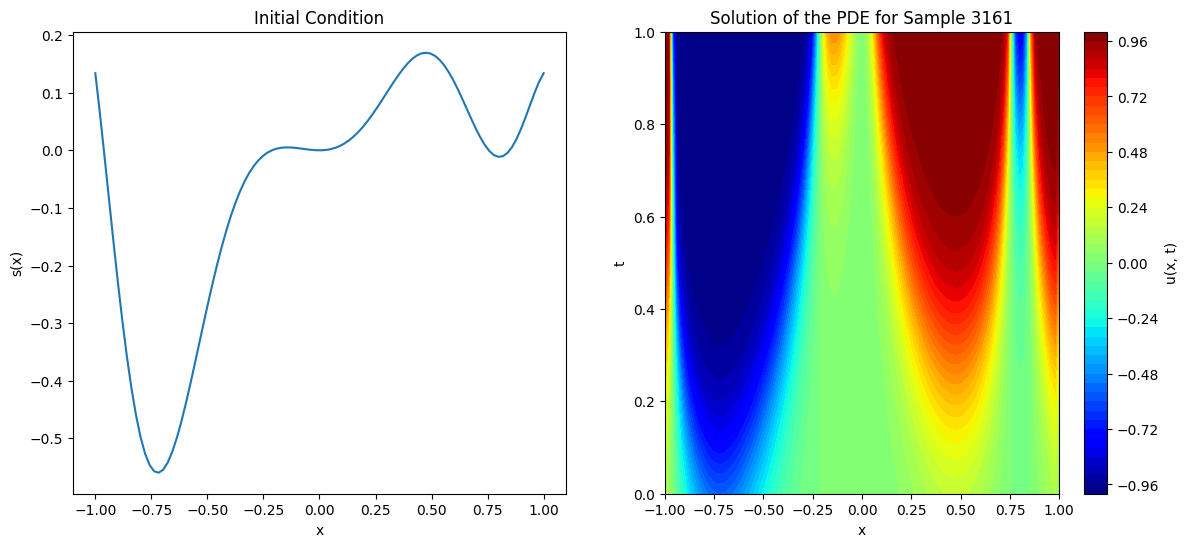

In [53]:
# Plot a random sample
sample_idx = np.random.randint(num_samples)
X, T = np.meshgrid(x, t)
plt.figure(figsize=(14, 6))
plt.subplot(1,2,2)
plt.contourf(X, T, u_train[sample_idx].T, levels=50, cmap='jet')
plt.colorbar(label='u(x, t)')
plt.xlabel('x')
plt.ylabel('t')
plt.title(f'Solution of the PDE for Sample {sample_idx}')

plt.subplot(1,2,1)
plt.plot(x, s_train[sample_idx])
plt.xlabel('x')
plt.ylabel('s(x)')
plt.title(f'Initial Condition')
plt.show()